# 🤖 Model Training Pipeline — Flood Prediction

**Covers:** Baseline Model, Model Selection, Cross Validation, Training, Evaluation, Error Analysis, Optimization, Explainability, Save Model

**All files are manually uploaded and downloaded.**

---
## 📤 Upload Processed Data

In [ ]:
# ============================================================
# UPLOAD: train.csv, val.csv, pipeline_metadata.json
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import joblib
import time
import io
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='viridis')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# --- Upload files ---
try:
    from google.colab import files
    print('📤 Upload train.csv:')
    up1 = files.upload()
    train_df = pd.read_csv(io.BytesIO(list(up1.values())[0]))
    print('\n📤 Upload val.csv:')
    up2 = files.upload()
    val_df = pd.read_csv(io.BytesIO(list(up2.values())[0]))
    print('\n📤 Upload pipeline_metadata.json:')
    up3 = files.upload()
    metadata = json.loads(list(up3.values())[0].decode('utf-8'))
except ImportError:
    try:
        import tkinter as tk
        from tkinter import filedialog
        root = tk.Tk(); root.withdraw()
        print('📤 Select train.csv:')
        p1 = filedialog.askopenfilename(title='Select train.csv', filetypes=[('CSV','*.csv')])
        train_df = pd.read_csv(p1)
        print('📤 Select val.csv:')
        p2 = filedialog.askopenfilename(title='Select val.csv', filetypes=[('CSV','*.csv')])
        val_df = pd.read_csv(p2)
        print('📤 Select pipeline_metadata.json:')
        p3 = filedialog.askopenfilename(title='Select pipeline_metadata.json', filetypes=[('JSON','*.json')])
        with open(p3, 'r') as f:
            metadata = json.load(f)
        root.destroy()
    except Exception:
        p1 = input('Enter path to train.csv: ').strip().strip('"')
        train_df = pd.read_csv(p1)
        p2 = input('Enter path to val.csv: ').strip().strip('"')
        val_df = pd.read_csv(p2)
        p3 = input('Enter path to pipeline_metadata.json: ').strip().strip('"')
        with open(p3, 'r') as f:
            metadata = json.load(f)

TARGET_COL = metadata['target_column']
PROBLEM_TYPE = metadata['problem_type']
IMBALANCED = metadata.get('imbalanced', False)

X_train = train_df.drop(columns=[TARGET_COL])
y_train = train_df[TARGET_COL]
X_val = val_df.drop(columns=[TARGET_COL])
y_val = val_df[TARGET_COL]

print(f'\n{"="*60}')
print('📥 DATA LOADED')
print(f'{"="*60}')
print(f'  Problem: {PROBLEM_TYPE.upper()} | Imbalanced: {IMBALANCED}')
print(f'  Train: {X_train.shape} | Val: {X_val.shape}')
print(f'  Target (Train): {dict(y_train.value_counts())}')

📤 Upload train.csv:


Saving train (1).csv to train (1).csv

📤 Upload val.csv:


Saving val (1).csv to val (1).csv

📤 Upload pipeline_metadata.json:


Saving pipeline_metadata (1).json to pipeline_metadata (1).json

📥 DATA LOADED
  Problem: CLASSIFICATION | Imbalanced: True
  Train: (17500, 39) | Val: (3750, 39)
  Target (Train): {0: np.int64(15770), 1: np.int64(1730)}


---
## 🔟 Baseline Model

In [ ]:
# ============================================================
# 10. BASELINE MODEL
# ============================================================
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_auc_score,
    mean_squared_error, mean_absolute_error, r2_score
)

print(f'{"="*60}')
print('📏 BASELINE MODEL')
print(f'{"="*60}')

baselines = {}
if PROBLEM_TYPE == 'classification':
    avg = 'weighted' if metadata['n_classes'] > 2 else 'binary'
    for strategy in ['most_frequent', 'stratified', 'uniform']:
        dummy = DummyClassifier(strategy=strategy, random_state=RANDOM_STATE)
        dummy.fit(X_train, y_train)
        y_pred_d = dummy.predict(X_val)
        baselines[f'Dummy ({strategy})'] = {
            'Accuracy': accuracy_score(y_val, y_pred_d),
            'F1': f1_score(y_val, y_pred_d, average=avg, zero_division=0),
            'Precision': precision_score(y_val, y_pred_d, average=avg, zero_division=0),
            'Recall': recall_score(y_val, y_pred_d, average=avg, zero_division=0)
        }
    baseline_df = pd.DataFrame(baselines).T
    BASELINE_F1 = float(baseline_df['F1'].max())
    print(f'  ⚠️ Any model must beat F1 = {BASELINE_F1:.4f}')
else:
    for strategy in ['mean', 'median']:
        dummy = DummyRegressor(strategy=strategy)
        dummy.fit(X_train, y_train)
        y_pred_d = dummy.predict(X_val)
        baselines[f'Dummy ({strategy})'] = {
            'RMSE': np.sqrt(mean_squared_error(y_val, y_pred_d)),
            'MAE': mean_absolute_error(y_val, y_pred_d),
            'R²': r2_score(y_val, y_pred_d)
        }
    baseline_df = pd.DataFrame(baselines).T
    BASELINE_RMSE = float(baseline_df['RMSE'].min())

display(baseline_df)

📏 BASELINE MODEL
  ⚠️ Any model must beat F1 = 0.1674


,Accuracy,F1,Precision,Recall
Dummy (most_frequent),0.901067,0.000000,0.000000,0.000000
Dummy (stratified),0.818667,0.063361,0.064789,0.061995
Dummy (uniform),0.501333,0.167409,0.100267,0.506739


---
## 1️⃣1️⃣ Model Selection + 1️⃣3️⃣ Training

In [ ]:
# ============================================================
# 11 + 13. MODEL SELECTION + TRAINING (REGULARIZED)
# ============================================================
from sklearn.linear_model import LogisticRegression, Ridge, Lasso
from sklearn.ensemble import (
    RandomForestClassifier, RandomForestRegressor,
    GradientBoostingClassifier, GradientBoostingRegressor,
    AdaBoostClassifier, AdaBoostRegressor,
    ExtraTreesClassifier, ExtraTreesRegressor
)
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.naive_bayes import GaussianNB

HAS_XGB = False
try:
    from xgboost import XGBClassifier, XGBRegressor
    HAS_XGB = True
except ImportError:
    print('XGBoost not installed.')

HAS_LGBM = False
try:
    from lightgbm import LGBMClassifier, LGBMRegressor
    HAS_LGBM = True
except ImportError:
    print('LightGBM not installed.')

cw = 'balanced' if IMBALANCED else None

# ======== REGULARIZED MODELS (OVERFITTING FIX) ========
# All tree models now have constrained depth and minimum samples
if PROBLEM_TYPE == 'classification':
    models = {
        'Logistic Regression': LogisticRegression(
            max_iter=1000, random_state=RANDOM_STATE, class_weight=cw,
            C=1.0, penalty='l2'  # L2 regularization
        ),
        'Random Forest': RandomForestClassifier(
            n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1, class_weight=cw,
            max_depth=15, min_samples_split=10, min_samples_leaf=5,  # REGULARIZED
            max_features='sqrt'
        ),
        'Gradient Boosting': GradientBoostingClassifier(
            n_estimators=200, random_state=RANDOM_STATE,
            max_depth=5, learning_rate=0.1, subsample=0.8,  # REGULARIZED
            min_samples_split=10, min_samples_leaf=5
        ),
        'Extra Trees': ExtraTreesClassifier(
            n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1, class_weight=cw,
            max_depth=15, min_samples_split=10, min_samples_leaf=5  # REGULARIZED
        ),
        'KNN': KNeighborsClassifier(n_neighbors=7, n_jobs=-1),
        'Decision Tree': DecisionTreeClassifier(
            random_state=RANDOM_STATE, class_weight=cw,
            max_depth=10, min_samples_split=10, min_samples_leaf=5  # REGULARIZED
        ),
        'AdaBoost': AdaBoostClassifier(
            n_estimators=100, random_state=RANDOM_STATE, algorithm='SAMME',
            learning_rate=0.1  # REGULARIZED
        ),
        'Naive Bayes': GaussianNB(),
    }
    if HAS_XGB:
        spw = float((y_train == 0).sum()) / max(float((y_train == 1).sum()), 1) if IMBALANCED else 1
        models['XGBoost'] = XGBClassifier(
            n_estimators=200, random_state=RANDOM_STATE, use_label_encoder=False,
            eval_metric='logloss', verbosity=0, n_jobs=-1, scale_pos_weight=spw,
            max_depth=6, learning_rate=0.1, subsample=0.8,  # REGULARIZED
            colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=1.0,
            min_child_weight=5
        )
    if HAS_LGBM:
        models['LightGBM'] = LGBMClassifier(
            n_estimators=200, random_state=RANDOM_STATE, verbosity=-1, n_jobs=-1,
            is_unbalance=IMBALANCED,
            max_depth=10, learning_rate=0.1, reg_alpha=0.1, reg_lambda=1.0,  # REGULARIZED
            min_child_samples=20, subsample=0.8, colsample_bytree=0.8
        )
else:
    models = {
        'Ridge': Ridge(alpha=1.0),
        'Lasso': Lasso(alpha=0.1),
        'Random Forest': RandomForestRegressor(
            n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1,
            max_depth=15, min_samples_split=10, min_samples_leaf=5
        ),
        'Gradient Boosting': GradientBoostingRegressor(
            n_estimators=200, random_state=RANDOM_STATE,
            max_depth=5, learning_rate=0.1, subsample=0.8,
            min_samples_split=10, min_samples_leaf=5
        ),
        'Extra Trees': ExtraTreesRegressor(
            n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1,
            max_depth=15, min_samples_split=10, min_samples_leaf=5
        ),
        'KNN': KNeighborsRegressor(n_neighbors=7, n_jobs=-1),
        'Decision Tree': DecisionTreeRegressor(
            random_state=RANDOM_STATE,
            max_depth=10, min_samples_split=10, min_samples_leaf=5
        ),
        'AdaBoost': AdaBoostRegressor(
            n_estimators=100, random_state=RANDOM_STATE, learning_rate=0.1
        ),
    }
    if HAS_XGB:
        models['XGBoost'] = XGBRegressor(
            n_estimators=200, random_state=RANDOM_STATE, verbosity=0, n_jobs=-1,
            max_depth=6, learning_rate=0.1, subsample=0.8,
            colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=1.0,
            min_child_weight=5
        )
    if HAS_LGBM:
        models['LightGBM'] = LGBMRegressor(
            n_estimators=200, random_state=RANDOM_STATE, verbosity=-1, n_jobs=-1,
            max_depth=10, learning_rate=0.1, reg_alpha=0.1, reg_lambda=1.0,
            min_child_samples=20, subsample=0.8, colsample_bytree=0.8
        )

print(f'{"="*60}')
print(f'TRAINING {len(models)} MODELS (REGULARIZED)')
print(f'{"="*60}')
print('  Note: All tree models now have constrained depth/complexity')
print('  to prevent overfitting (max_depth, min_samples_split, etc.)\n')

results = {}
trained_models = {}

for name, model in models.items():
    print(f'  {name}...', end=' ')
    start = time.time()
    try:
        model.fit(X_train, y_train)
        elapsed = time.time() - start
        y_pred_t = model.predict(X_train)
        y_pred_v = model.predict(X_val)
        if PROBLEM_TYPE == 'classification':
            res = {
                'Train Acc': accuracy_score(y_train, y_pred_t),
                'Val Acc': accuracy_score(y_val, y_pred_v),
                'Val Precision': precision_score(y_val, y_pred_v, average=avg, zero_division=0),
                'Val Recall': recall_score(y_val, y_pred_v, average=avg, zero_division=0),
                'Val F1': f1_score(y_val, y_pred_v, average=avg, zero_division=0),
                'Overfit Gap': accuracy_score(y_train, y_pred_t) - accuracy_score(y_val, y_pred_v),
                'Time (s)': round(elapsed, 2)
            }
            try:
                if hasattr(model, 'predict_proba'):
                    yp = model.predict_proba(X_val)
                    if metadata['n_classes'] == 2:
                        res['Val AUC'] = roc_auc_score(y_val, yp[:, 1])
                    else:
                        res['Val AUC'] = roc_auc_score(y_val, yp, multi_class='ovr', average='weighted')
            except Exception:
                res['Val AUC'] = np.nan
            results[name] = res
        else:
            results[name] = {
                'Train RMSE': np.sqrt(mean_squared_error(y_train, y_pred_t)),
                'Val RMSE': np.sqrt(mean_squared_error(y_val, y_pred_v)),
                'Val MAE': mean_absolute_error(y_val, y_pred_v),
                'Val R2': r2_score(y_val, y_pred_v),
                'Overfit Gap': np.sqrt(mean_squared_error(y_val, y_pred_v)) - np.sqrt(mean_squared_error(y_train, y_pred_t)),
                'Time (s)': round(elapsed, 2)
            }
        trained_models[name] = model
        print(f'Done ({elapsed:.2f}s)')
    except Exception as e:
        print(f'FAILED: {e}')


TRAINING 10 MODELS (REGULARIZED)
  Note: All tree models now have constrained depth/complexity
  to prevent overfitting (max_depth, min_samples_split, etc.)

  Logistic Regression... Done (0.15s)
  Random Forest... Done (8.11s)
  Gradient Boosting... Done (35.76s)
  Extra Trees... Done (2.24s)
  KNN... Done (0.01s)
  Decision Tree... Done (0.37s)
  AdaBoost... Done (4.70s)
  Naive Bayes... Done (0.02s)
  XGBoost... Done (2.31s)
  LightGBM... Done (0.96s)


---
## 1️⃣4️⃣ Evaluation

In [ ]:
# ============================================================
# 14. EVALUATION
# ============================================================
results_df = pd.DataFrame(results).T.dropna(axis=1, how='all')

if PROBLEM_TYPE == 'classification':
    sort_col = 'Val F1'
    results_df = results_df.sort_values(sort_col, ascending=False)
else:
    sort_col = 'Val RMSE'
    results_df = results_df.sort_values(sort_col, ascending=True)

print(f'\n{"="*60}')
print(f'📊 MODEL COMPARISON (by {sort_col})')
print(f'{"="*60}')
display(results_df)

# Select best
if PROBLEM_TYPE == 'classification':
    best_model_name = results_df[sort_col].astype(float).idxmax()
    best_metric = float(results_df.loc[best_model_name, sort_col])
    improvement = best_metric - BASELINE_F1
    print(f'\n🏆 Best: {best_model_name} ({sort_col}={best_metric:.4f}, +{improvement:.4f} vs baseline)')
else:
    best_model_name = results_df[sort_col].astype(float).idxmin()
    best_metric = float(results_df.loc[best_model_name, sort_col])
    print(f'\n🏆 Best: {best_model_name} ({sort_col}={best_metric:.4f})')

best_model = trained_models[best_model_name]


📊 MODEL COMPARISON (by Val F1)


,Train Acc,Val Acc,Val Precision,Val Recall,Val F1,Overfit Gap,Time (s),Val AUC
XGBoost,0.961886,0.918667,0.560219,0.827493,0.668118,0.043219,2.31,0.958166
LightGBM,0.968457,0.917067,0.553957,0.830189,0.664509,0.051390,0.96,0.956457
Random Forest,0.959143,0.920800,0.573413,0.778976,0.660571,0.038343,8.11,0.953019
Extra Trees,0.937543,0.901333,0.500816,0.827493,0.623984,0.036210,2.24,0.945434
Decision Tree,0.905200,0.877067,0.436975,0.840970,0.575115,0.028133,0.37,0.871156
Gradient Boosting,0.981829,0.918933,0.609121,0.504043,0.551622,0.062895,35.76,0.954546
Logistic Regression,0.845543,0.840000,0.370621,0.884097,0.522293,0.005543,0.15,0.925034
Naive Bayes,0.891886,0.886133,0.405405,0.323450,0.359820,0.005752,0.02,0.881008
KNN,0.916571,0.904267,0.576923,0.121294,0.200445,0.012305,0.01,0.784424
AdaBoost,0.901143,0.901067,0.000000,0.000000,0.000000,0.000076,4.70,0.909830



🏆 Best: XGBoost (Val F1=0.6681, +0.5007 vs baseline)


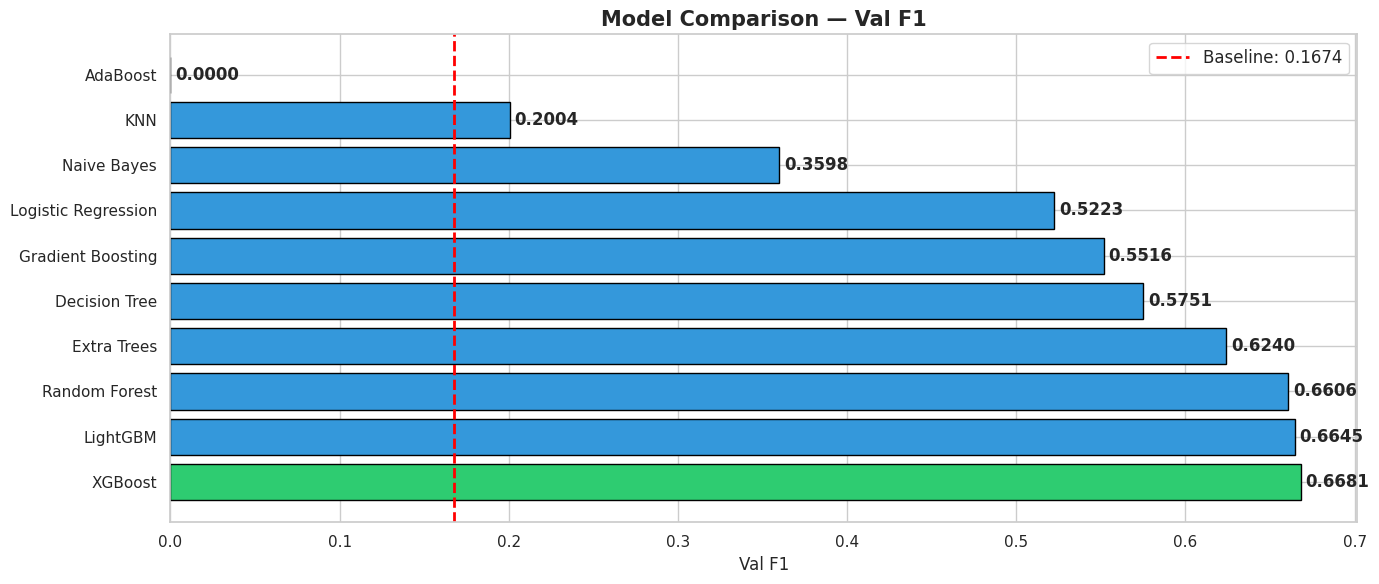

In [ ]:
# --- Model comparison chart ---
fig, ax = plt.subplots(figsize=(14, 6))
colors = ['#2ecc71' if n == best_model_name else '#3498db' for n in results_df.index]
bars = ax.barh(results_df.index, results_df[sort_col].astype(float), color=colors, edgecolor='black')
if PROBLEM_TYPE == 'classification':
    ax.axvline(BASELINE_F1, color='red', linestyle='--', lw=2, label=f'Baseline: {BASELINE_F1:.4f}')
ax.set_xlabel(sort_col)
ax.set_title(f'Model Comparison — {sort_col}', fontsize=15, fontweight='bold')
for bar, val in zip(bars, results_df[sort_col].astype(float)):
    ax.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height() / 2, f'{val:.4f}', ha='left', va='center', fontweight='bold')
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

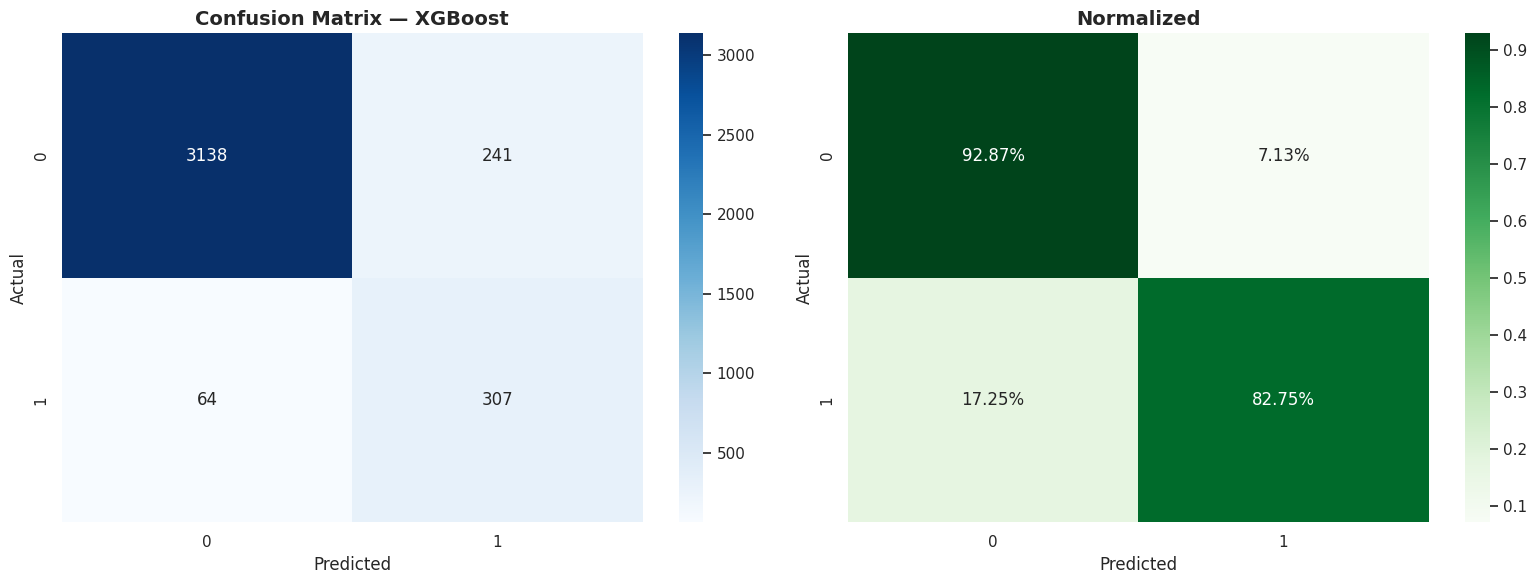


📋 Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.93      0.95      3379
           1       0.56      0.83      0.67       371

    accuracy                           0.92      3750
   macro avg       0.77      0.88      0.81      3750
weighted avg       0.94      0.92      0.93      3750



In [ ]:
# --- Confusion Matrix / Prediction Plot ---
y_pred_best = best_model.predict(X_val)

if PROBLEM_TYPE == 'classification':
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    cm = confusion_matrix(y_val, y_pred_best)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
    axes[0].set_title(f'Confusion Matrix — {best_model_name}', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')
    cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Greens', ax=axes[1])
    axes[1].set_title('Normalized', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Actual')
    plt.tight_layout(); plt.show()
    print('\n📋 Classification Report:')
    print(classification_report(y_val, y_pred_best))
else:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    axes[0].scatter(y_val, y_pred_best, alpha=0.4, s=10)
    axes[0].plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--', lw=2)
    axes[0].set_title('Actual vs Predicted', fontsize=14, fontweight='bold')
    residuals = y_val - y_pred_best
    axes[1].scatter(y_pred_best, residuals, alpha=0.4, s=10, color='#e74c3c')
    axes[1].axhline(0, color='black', linestyle='--')
    axes[1].set_title('Residuals', fontsize=14, fontweight='bold')
    plt.tight_layout(); plt.show()

---
## 1️⃣5️⃣ Error Analysis

🔍 ERROR ANALYSIS
  ❌ Misclassified: 305 / 3750 (8.1%)


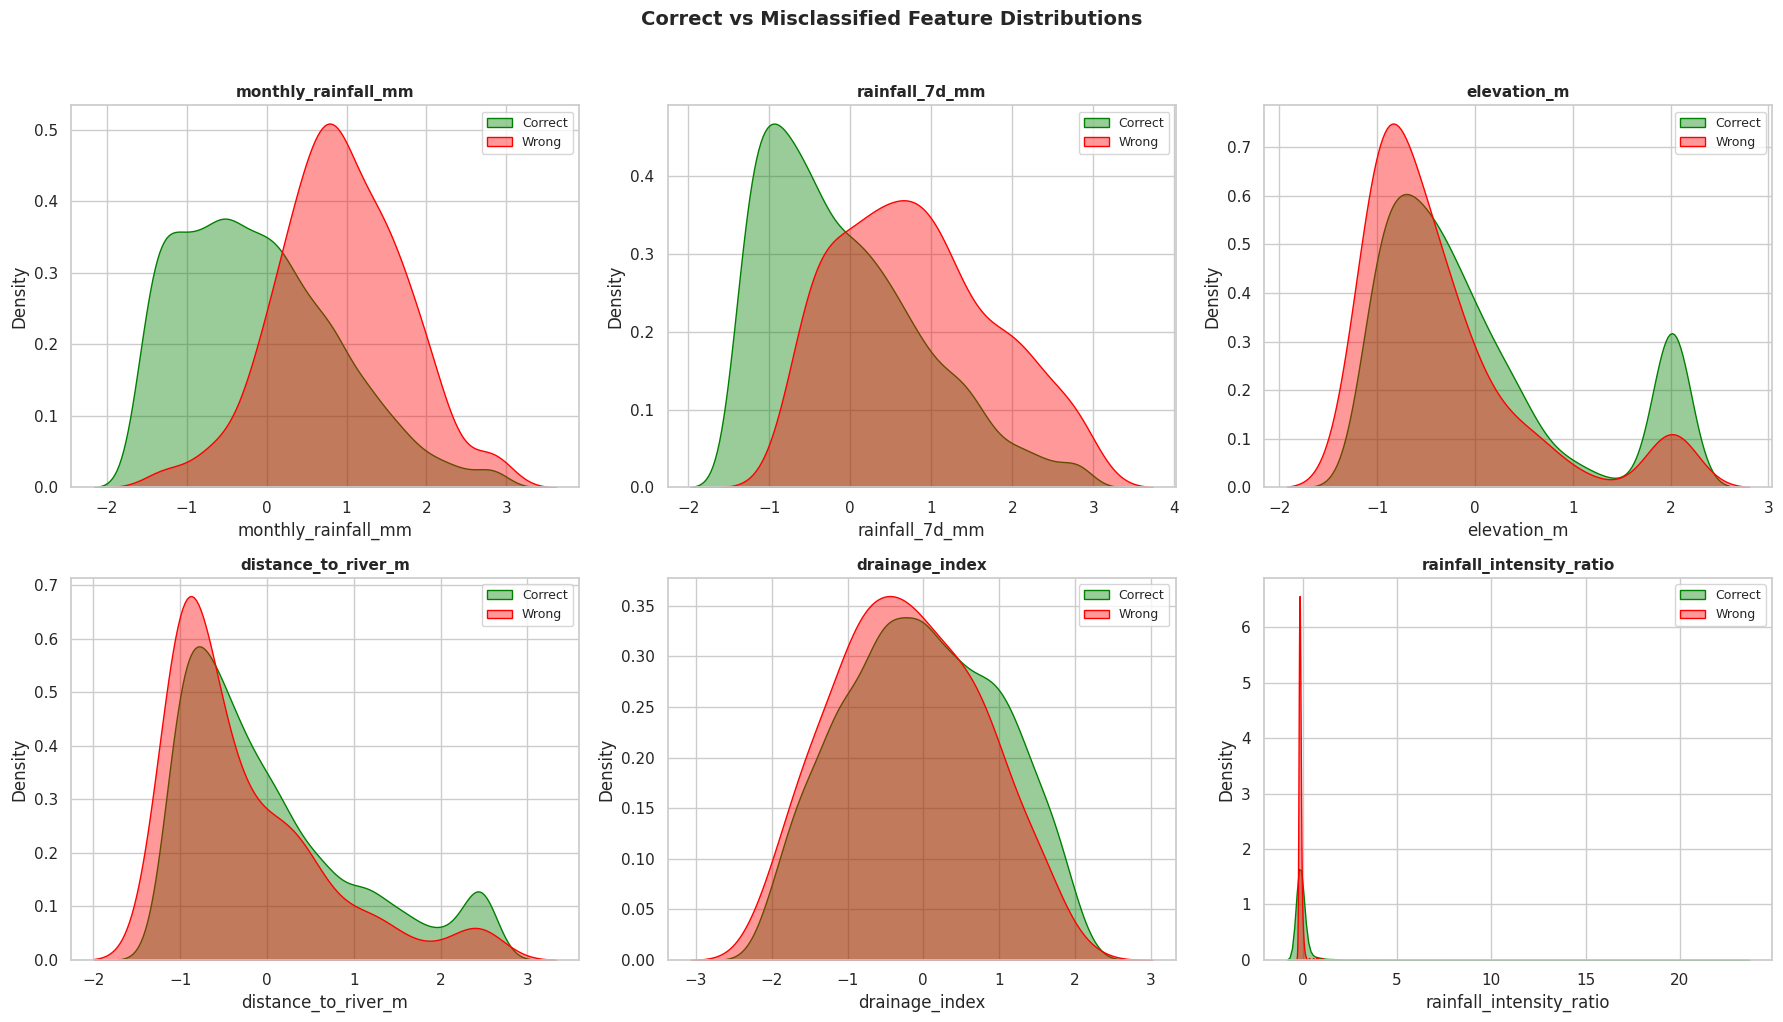

In [ ]:
# ============================================================
# 15. ERROR ANALYSIS
# ============================================================

print(f'{"="*60}')
print('🔍 ERROR ANALYSIS')
print(f'{"="*60}')

if PROBLEM_TYPE == 'classification':
    correct_mask = (y_pred_best == y_val.values)
    n_wrong = int((~correct_mask).sum())
    print(f'  ❌ Misclassified: {n_wrong} / {len(y_val)} ({n_wrong / len(y_val) * 100:.1f}%)')

    # Feature distributions: correct vs wrong
    diff_means = {}
    for col in X_val.columns[:20]:
        mean_c = X_val.loc[correct_mask, col].mean()
        mean_w = X_val.loc[~correct_mask, col].mean()
        diff_means[col] = abs(mean_c - mean_w) if not (np.isnan(mean_c) or np.isnan(mean_w)) else 0

    top_diff = sorted(diff_means.items(), key=lambda x: x[1], reverse=True)[:6]
    n_plot = min(6, len(top_diff))
    if n_plot > 0:
        fig, axes = plt.subplots(2, 3, figsize=(18, 10))
        axes = axes.flatten()
        for i in range(n_plot):
            col = top_diff[i][0]
            d_correct = X_val.loc[correct_mask, col].dropna()
            d_wrong = X_val.loc[~correct_mask, col].dropna()
            if len(d_correct) > 1 and d_correct.std() > 0:
                sns.kdeplot(d_correct, ax=axes[i], fill=True, alpha=0.4, label='Correct', color='green')
            if len(d_wrong) > 1 and d_wrong.std() > 0:
                sns.kdeplot(d_wrong, ax=axes[i], fill=True, alpha=0.4, label='Wrong', color='red')
            axes[i].set_title(col, fontsize=11, fontweight='bold')
            axes[i].legend(fontsize=9)
        for j in range(n_plot, len(axes)):
            axes[j].set_visible(False)
        plt.suptitle('Correct vs Misclassified Feature Distributions', fontsize=14, fontweight='bold', y=1.02)
        plt.tight_layout(); plt.show()
else:
    residuals = y_val - y_pred_best
    print(f'  Mean Error:  {residuals.mean():.4f}')
    print(f'  Error Std:   {residuals.std():.4f}')

---
## 1️⃣2️⃣ Cross Validation + 1️⃣6️⃣ Optimization

HYPERPARAMETER TUNING (ANTI-OVERFITTING) - XGBoost
Fitting 5 folds for each of 40 candidates, totalling 200 fits

Best params: {'subsample': 0.8, 'reg_lambda': 2.0, 'reg_alpha': 1.0, 'n_estimators': 300, 'min_child_weight': 7, 'max_depth': 10, 'learning_rate': 0.05, 'colsample_bytree': 0.7}
   Best CV score: 0.9226

5-Fold CV (Stratified):
   Scores: [0.9209 0.9219 0.9259 0.9212 0.923 ]
   Mean:   0.9226 +/- 0.0018


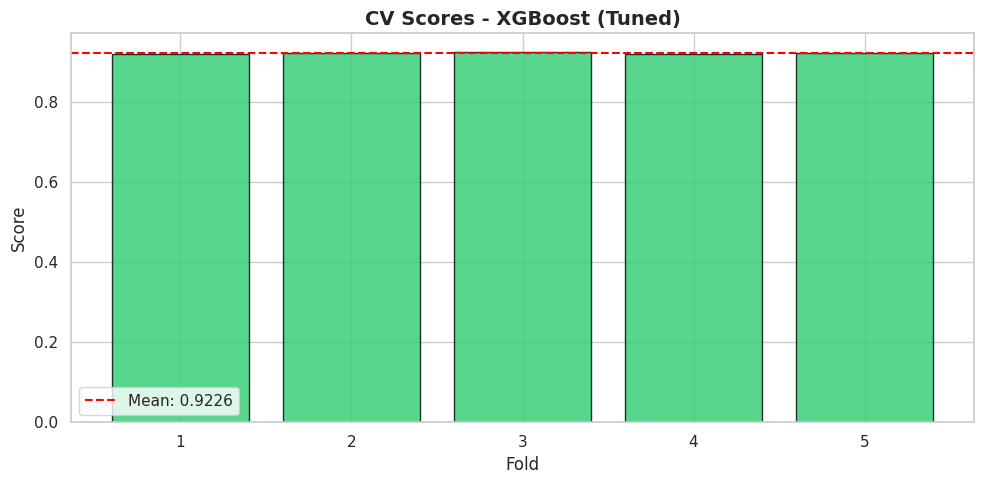

In [ ]:
# ============================================================
# 12 + 16. CROSS VALIDATION + HYPERPARAMETER TUNING (IMPROVED)
# ============================================================
from sklearn.model_selection import RandomizedSearchCV, cross_val_score, StratifiedKFold

print(f'{"="*60}')
print(f'HYPERPARAMETER TUNING (ANTI-OVERFITTING) - {best_model_name}')
print(f'{"="*60}')

# Constrained param grids to prevent overfitting
param_grids = {
    'Random Forest': {
        'n_estimators': [100, 200, 300, 500],
        'max_depth': [5, 10, 15, 20],  # No None!
        'min_samples_split': [5, 10, 15, 20],
        'min_samples_leaf': [3, 5, 8, 10],
        'max_features': ['sqrt', 'log2']
    },
    'Gradient Boosting': {
        'n_estimators': [100, 200, 300],
        'learning_rate': [0.01, 0.05, 0.1],
        'max_depth': [3, 5, 7],
        'subsample': [0.7, 0.8, 0.9],
        'min_samples_split': [5, 10, 15],
        'min_samples_leaf': [3, 5, 8]
    },
    'XGBoost': {
        'n_estimators': [100, 200, 300, 500],
        'learning_rate': [0.01, 0.05, 0.1],
        'max_depth': [3, 5, 7, 10],
        'subsample': [0.7, 0.8, 0.9],
        'colsample_bytree': [0.7, 0.8, 0.9],
        'reg_alpha': [0, 0.1, 0.5, 1.0],
        'reg_lambda': [0.5, 1.0, 2.0],
        'min_child_weight': [3, 5, 7, 10]
    },
    'LightGBM': {
        'n_estimators': [100, 200, 300, 500],
        'learning_rate': [0.01, 0.05, 0.1],
        'max_depth': [5, 10, 15],
        'num_leaves': [15, 31, 50],
        'min_child_samples': [10, 20, 30],
        'reg_alpha': [0, 0.1, 0.5],
        'reg_lambda': [0.5, 1.0, 2.0],
        'subsample': [0.7, 0.8, 0.9]
    },
    'Extra Trees': {
        'n_estimators': [100, 200, 300, 500],
        'max_depth': [5, 10, 15, 20],
        'min_samples_split': [5, 10, 15],
        'min_samples_leaf': [3, 5, 8]
    },
    'KNN': {
        'n_neighbors': [3, 5, 7, 9, 11, 15],
        'weights': ['uniform', 'distance']
    },
    'Logistic Regression': {
        'C': [0.01, 0.1, 1, 10],
        'solver': ['lbfgs', 'liblinear']
    }
}

if best_model_name in param_grids:
    scoring = 'f1_weighted' if PROBLEM_TYPE == 'classification' else 'neg_root_mean_squared_error'
    cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE) if PROBLEM_TYPE == 'classification' else 5
    search = RandomizedSearchCV(
        best_model, param_grids[best_model_name],
        n_iter=40, cv=cv_strategy, scoring=scoring,
        random_state=RANDOM_STATE, n_jobs=-1, verbose=1
    )
    search.fit(X_train, y_train)
    print(f'\nBest params: {search.best_params_}')
    print(f'   Best CV score: {search.best_score_:.4f}')
    best_model = search.best_estimator_
    best_model_name = f'{best_model_name} (Tuned)'
else:
    print(f'  No tuning grid for {best_model_name}. Using defaults.')

# Cross-validation with stratified K-fold
scoring = 'f1_weighted' if PROBLEM_TYPE == 'classification' else 'neg_root_mean_squared_error'
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE) if PROBLEM_TYPE == 'classification' else 5
cv_scores = cross_val_score(best_model, X_train, y_train, cv=cv_strategy, scoring=scoring, n_jobs=-1)

print(f'\n5-Fold CV (Stratified):')
print(f'   Scores: {cv_scores.round(4)}')
print(f'   Mean:   {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}')

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(range(1, 6), cv_scores, color='#2ecc71', edgecolor='black', alpha=0.8)
ax.axhline(cv_scores.mean(), color='red', linestyle='--', label=f'Mean: {cv_scores.mean():.4f}')
ax.set_xlabel('Fold'); ax.set_ylabel('Score')
ax.set_title(f'CV Scores - {best_model_name}', fontsize=14, fontweight='bold')
ax.legend(); ax.set_xticks(range(1, 6))
plt.tight_layout(); plt.show()


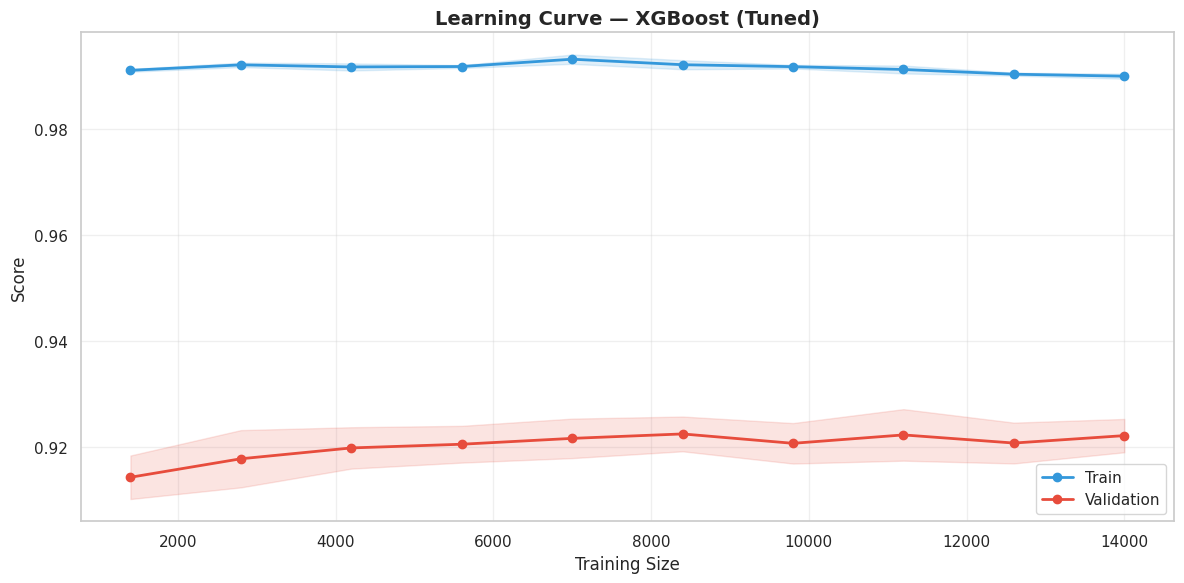

  Gap: 0.0678 → ⚠️ Possible overfitting


In [ ]:
# --- Learning Curves ---
from sklearn.model_selection import learning_curve

scoring_lc = 'f1_weighted' if PROBLEM_TYPE == 'classification' else 'neg_root_mean_squared_error'
train_sizes, train_scores, val_scores = learning_curve(
    best_model, X_train, y_train, cv=5, n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10), scoring=scoring_lc
)
t_mean = train_scores.mean(axis=1); t_std = train_scores.std(axis=1)
v_mean = val_scores.mean(axis=1); v_std = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(train_sizes, t_mean, 'o-', color='#3498db', label='Train', lw=2)
ax.fill_between(train_sizes, t_mean - t_std, t_mean + t_std, alpha=0.15, color='#3498db')
ax.plot(train_sizes, v_mean, 'o-', color='#e74c3c', label='Validation', lw=2)
ax.fill_between(train_sizes, v_mean - v_std, v_mean + v_std, alpha=0.15, color='#e74c3c')
ax.set_title(f'Learning Curve — {best_model_name}', fontsize=14, fontweight='bold')
ax.set_xlabel('Training Size'); ax.set_ylabel('Score')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

gap = abs(t_mean[-1] - v_mean[-1])
print(f'  Gap: {gap:.4f} → {"✅ No overfitting" if gap < 0.05 else "⚠️ Possible overfitting"}')

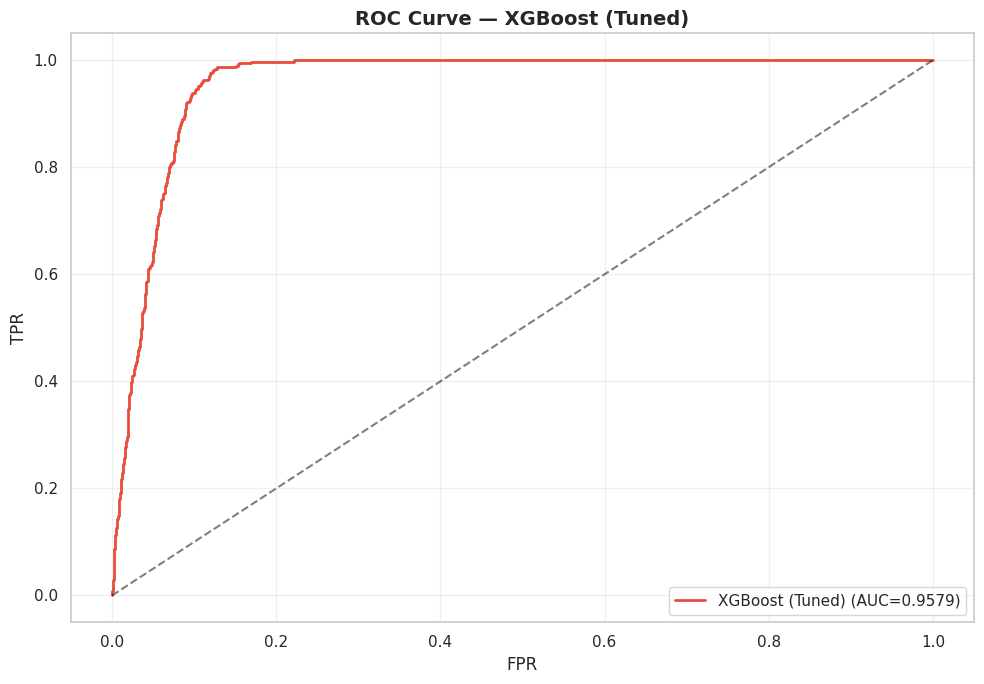

In [ ]:
# --- ROC Curve ---
if PROBLEM_TYPE == 'classification' and hasattr(best_model, 'predict_proba'):
    from sklearn.metrics import roc_curve, auc
    fig, ax = plt.subplots(figsize=(10, 7))
    if metadata['n_classes'] == 2:
        yp = best_model.predict_proba(X_val)[:, 1]
        fpr, tpr, _ = roc_curve(y_val, yp)
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, color='#e74c3c', lw=2, label=f'{best_model_name} (AUC={roc_auc:.4f})')
    else:
        from sklearn.preprocessing import label_binarize
        y_val_bin = label_binarize(y_val, classes=metadata['class_labels'])
        yp = best_model.predict_proba(X_val)
        for idx_cls, cls in enumerate(metadata['class_labels']):
            fpr, tpr, _ = roc_curve(y_val_bin[:, idx_cls], yp[:, idx_cls])
            roc_auc = auc(fpr, tpr)
            ax.plot(fpr, tpr, lw=2, label=f'Class {cls} (AUC={roc_auc:.4f})')
    ax.plot([0,1],[0,1],'k--', alpha=0.5)
    ax.set_title(f'ROC Curve — {best_model_name}', fontsize=14, fontweight='bold')
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
    ax.legend(); ax.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

---
## ADDED: Train vs Validation Overfitting Analysis


TRAIN vs VALIDATION — OVERFITTING ANALYSIS


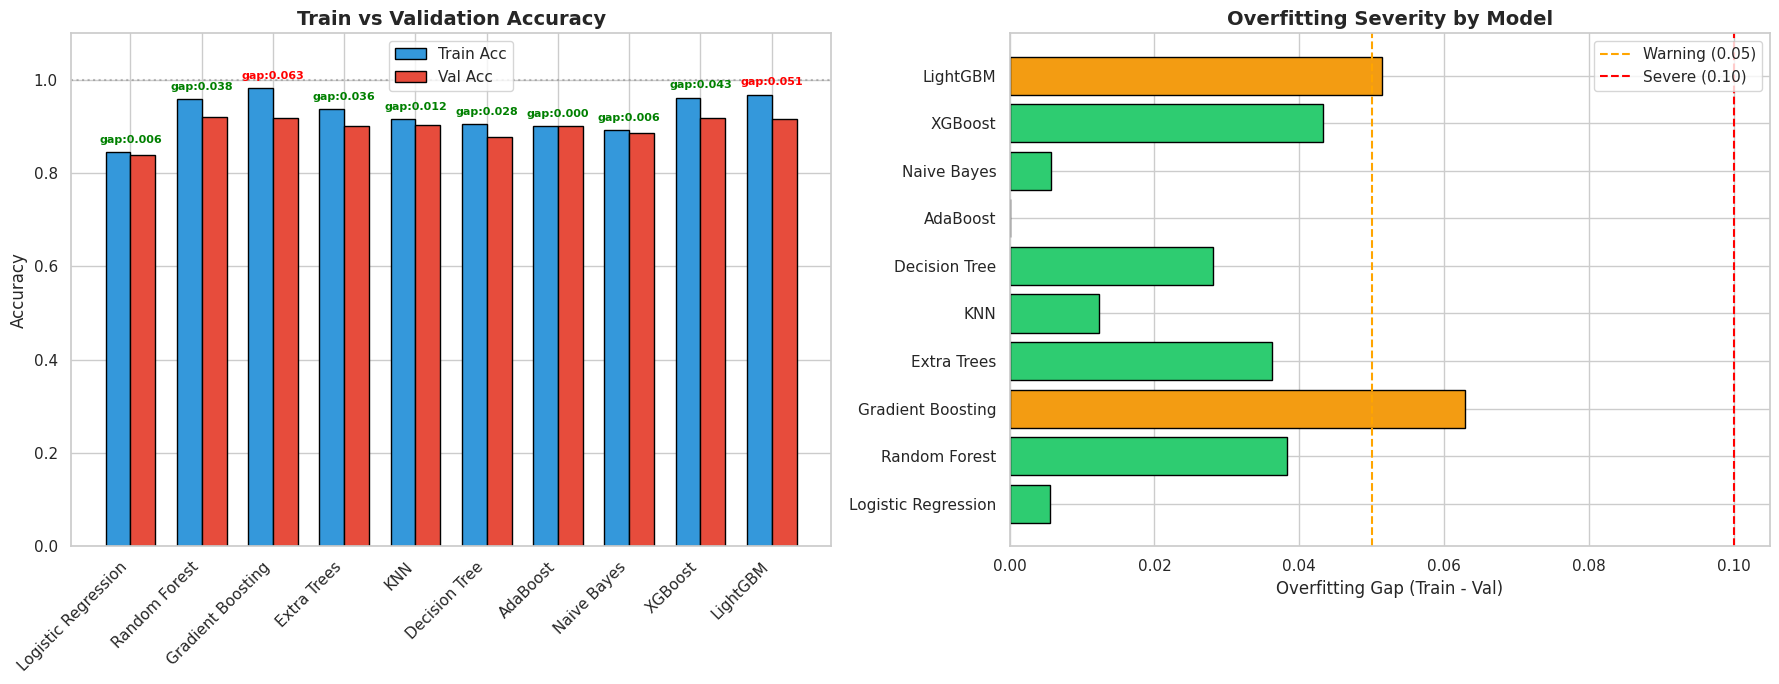


Overfitting Summary:
   Logistic Regression: Train=0.8455 Val=0.8400 Gap=0.0055 [OK]
   Random Forest: Train=0.9591 Val=0.9208 Gap=0.0383 [OK]
   Gradient Boosting: Train=0.9818 Val=0.9189 Gap=0.0629 [WARNING]
   Extra Trees: Train=0.9375 Val=0.9013 Gap=0.0362 [OK]
   KNN: Train=0.9166 Val=0.9043 Gap=0.0123 [OK]
   Decision Tree: Train=0.9052 Val=0.8771 Gap=0.0281 [OK]
   AdaBoost: Train=0.9011 Val=0.9011 Gap=0.0001 [OK]
   Naive Bayes: Train=0.8919 Val=0.8861 Gap=0.0058 [OK]
   XGBoost: Train=0.9619 Val=0.9187 Gap=0.0432 [OK]
   LightGBM: Train=0.9685 Val=0.9171 Gap=0.0514 [WARNING]


In [ ]:
# ============================================================
# TRAIN vs VALIDATION COMPARISON (OVERFITTING DETECTOR)
# ============================================================

print(f'{"="*60}')
print('TRAIN vs VALIDATION — OVERFITTING ANALYSIS')
print(f'{"="*60}')

if PROBLEM_TYPE == 'classification':
    # --- 1. Overfitting gap bar chart ---
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))

    model_names = list(results.keys())
    train_accs = [results[n]['Train Acc'] for n in model_names]
    val_accs = [results[n]['Val Acc'] for n in model_names]
    val_f1s = [results[n]['Val F1'] for n in model_names]
    gaps = [t - v for t, v in zip(train_accs, val_accs)]

    x = np.arange(len(model_names))
    width = 0.35
    b1 = axes[0].bar(x - width/2, train_accs, width, label='Train Acc', color='#3498db', edgecolor='black')
    b2 = axes[0].bar(x + width/2, val_accs, width, label='Val Acc', color='#e74c3c', edgecolor='black')
    axes[0].set_ylabel('Accuracy')
    axes[0].set_title('Train vs Validation Accuracy', fontsize=14, fontweight='bold')
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(model_names, rotation=45, ha='right')
    axes[0].legend(fontsize=11)
    axes[0].set_ylim(0, 1.1)
    axes[0].axhline(1.0, color='gray', linestyle=':', alpha=0.5)

    # Annotate gaps
    for idx, (t, v) in enumerate(zip(train_accs, val_accs)):
        gap = t - v
        color = 'red' if gap > 0.05 else 'green'
        axes[0].annotate(f'gap:{gap:.3f}', (idx, max(t, v) + 0.02), ha='center', fontsize=8, color=color, fontweight='bold')

    # --- 2. Overfitting severity ---
    colors = ['#e74c3c' if g > 0.1 else '#f39c12' if g > 0.05 else '#2ecc71' for g in gaps]
    axes[1].barh(model_names, gaps, color=colors, edgecolor='black')
    axes[1].axvline(0.05, color='orange', linestyle='--', label='Warning (0.05)')
    axes[1].axvline(0.10, color='red', linestyle='--', label='Severe (0.10)')
    axes[1].set_xlabel('Overfitting Gap (Train - Val)')
    axes[1].set_title('Overfitting Severity by Model', fontsize=14, fontweight='bold')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    # Print summary
    print('\nOverfitting Summary:')
    for name in model_names:
        gap = results[name].get('Overfit Gap', results[name]['Train Acc'] - results[name]['Val Acc'])
        status = 'SEVERE' if gap > 0.10 else 'WARNING' if gap > 0.05 else 'OK'
        print(f'   {name}: Train={results[name]["Train Acc"]:.4f} Val={results[name]["Val Acc"]:.4f} Gap={gap:.4f} [{status}]')
else:
    print('  Regression mode — see residual plots above.')


---
## ADDED: Precision-Recall Curve


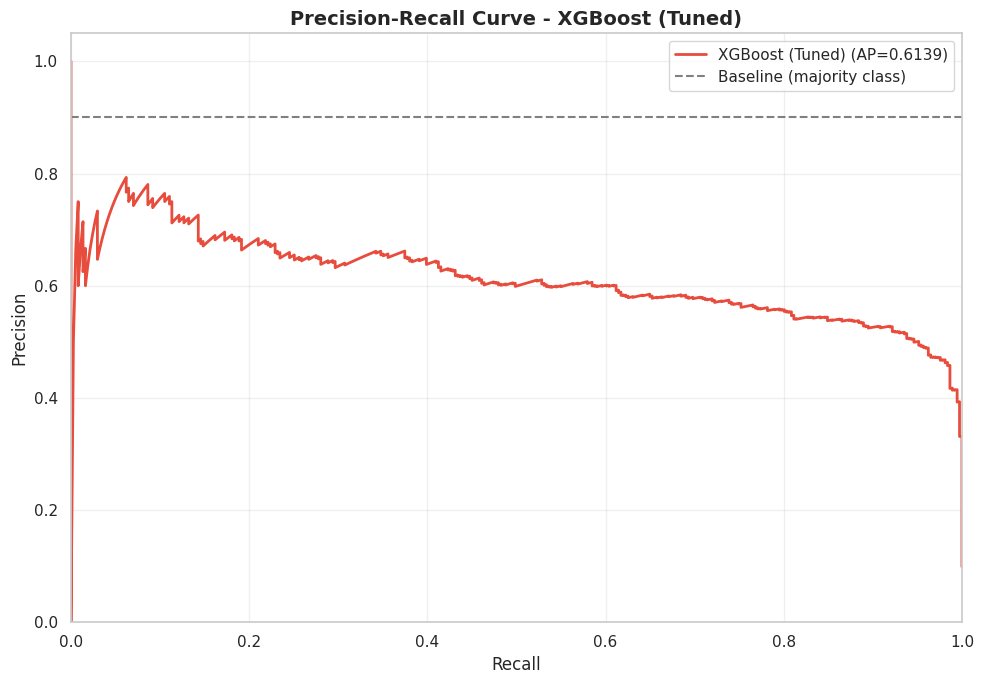

In [ ]:
# ============================================================
# PRECISION-RECALL CURVE (ADDED)
# ============================================================
if PROBLEM_TYPE == 'classification' and hasattr(best_model, 'predict_proba'):
    from sklearn.metrics import precision_recall_curve, average_precision_score

    fig, ax = plt.subplots(figsize=(10, 7))
    if metadata['n_classes'] == 2:
        yp_val = best_model.predict_proba(X_val)[:, 1]
        precision_vals, recall_vals, _ = precision_recall_curve(y_val, yp_val)
        ap = average_precision_score(y_val, yp_val)
        ax.plot(recall_vals, precision_vals, color='#e74c3c', lw=2,
                label=f'{best_model_name} (AP={ap:.4f})')
        ax.axhline(y_val.value_counts(normalize=True).max(), color='gray',
                   linestyle='--', label='Baseline (majority class)')
    else:
        from sklearn.preprocessing import label_binarize
        y_val_bin = label_binarize(y_val, classes=metadata['class_labels'])
        yp_val = best_model.predict_proba(X_val)
        for idx_cls, cls in enumerate(metadata['class_labels']):
            precision_vals, recall_vals, _ = precision_recall_curve(y_val_bin[:, idx_cls], yp_val[:, idx_cls])
            ap = average_precision_score(y_val_bin[:, idx_cls], yp_val[:, idx_cls])
            ax.plot(recall_vals, precision_vals, lw=2, label=f'Class {cls} (AP={ap:.4f})')

    ax.set_title(f'Precision-Recall Curve - {best_model_name}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
    ax.legend(fontsize=11); ax.grid(True, alpha=0.3)
    ax.set_xlim([0, 1]); ax.set_ylim([0, 1.05])
    plt.tight_layout(); plt.show()
else:
    print('  Precision-Recall curve requires classification with predict_proba.')


---
## ADDED: Error Distribution Plot


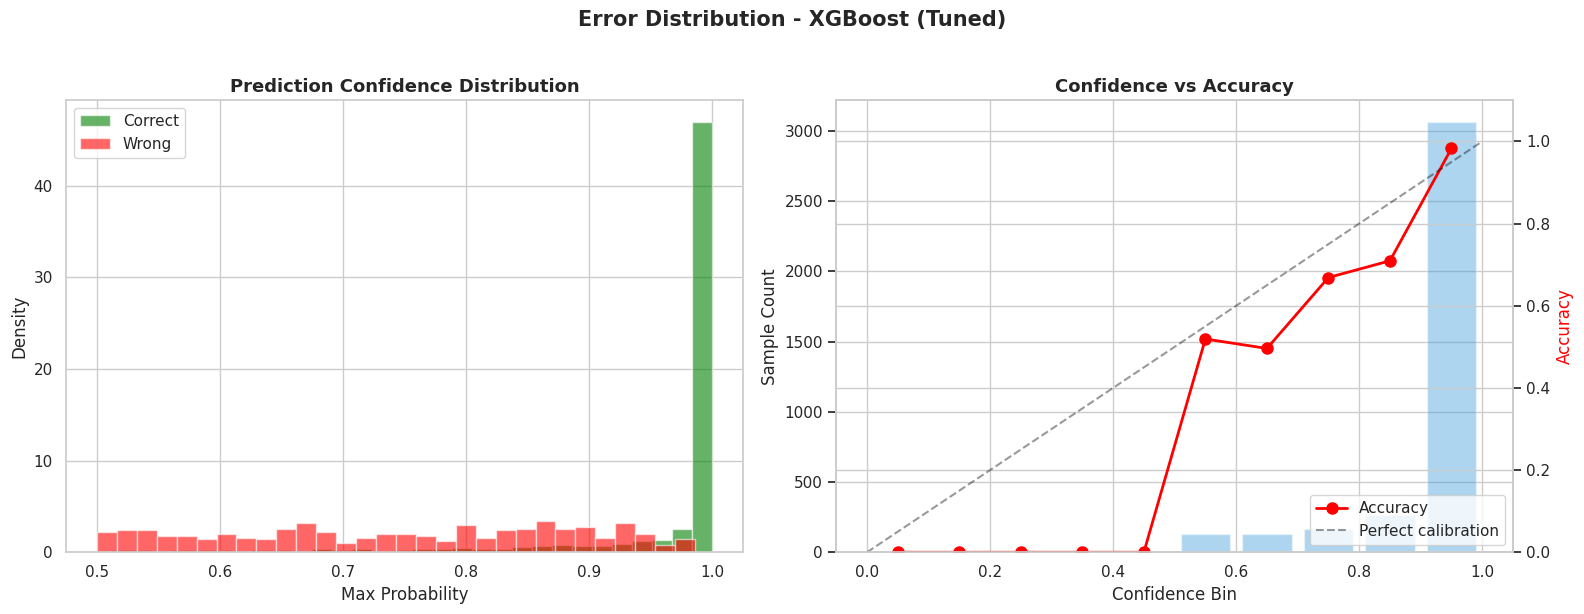

In [ ]:
# ============================================================
# ERROR DISTRIBUTION PLOT (ADDED)
# ============================================================

y_pred_final = best_model.predict(X_val)

if PROBLEM_TYPE == 'classification':
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # --- 1. Prediction confidence distribution ---
    if hasattr(best_model, 'predict_proba'):
        proba_val = best_model.predict_proba(X_val)
        max_proba = proba_val.max(axis=1)
        correct_mask_err = (y_pred_final == y_val.values)

        axes[0].hist(max_proba[correct_mask_err], bins=30, alpha=0.6, color='green',
                     label='Correct', edgecolor='white', density=True)
        axes[0].hist(max_proba[~correct_mask_err], bins=30, alpha=0.6, color='red',
                     label='Wrong', edgecolor='white', density=True)
        axes[0].set_title('Prediction Confidence Distribution', fontsize=13, fontweight='bold')
        axes[0].set_xlabel('Max Probability')
        axes[0].set_ylabel('Density')
        axes[0].legend(fontsize=11)

        # --- 2. Calibration-like plot ---
        bins_cal = np.linspace(0, 1, 11)
        bin_centers = (bins_cal[:-1] + bins_cal[1:]) / 2
        bin_accs = []
        bin_counts = []
        for left, right in zip(bins_cal[:-1], bins_cal[1:]):
            mask = (max_proba >= left) & (max_proba < right)
            if mask.sum() > 0:
                bin_accs.append(correct_mask_err[mask].mean())
                bin_counts.append(mask.sum())
            else:
                bin_accs.append(0)
                bin_counts.append(0)

        axes[1].bar(bin_centers, bin_counts, width=0.08, alpha=0.4, color='#3498db', label='Count')
        ax2 = axes[1].twinx()
        ax2.plot(bin_centers, bin_accs, 'ro-', lw=2, markersize=8, label='Accuracy')
        ax2.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Perfect calibration')
        ax2.set_ylabel('Accuracy', color='red')
        ax2.set_ylim(0, 1.1)
        ax2.legend(loc='lower right')
        axes[1].set_title('Confidence vs Accuracy', fontsize=13, fontweight='bold')
        axes[1].set_xlabel('Confidence Bin')
        axes[1].set_ylabel('Sample Count')
    else:
        axes[0].text(0.5, 0.5, 'No probabilities available', transform=axes[0].transAxes, ha='center')
        axes[1].text(0.5, 0.5, 'No probabilities available', transform=axes[1].transAxes, ha='center')

    plt.suptitle(f'Error Distribution - {best_model_name}', fontsize=15, fontweight='bold', y=1.02)
    plt.tight_layout(); plt.show()
else:
    # Regression error distribution
    residuals_err = y_val - y_pred_final
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    axes[0].hist(residuals_err, bins=50, color='#e74c3c', edgecolor='white', alpha=0.8)
    axes[0].axvline(0, color='black', linestyle='--')
    axes[0].set_title('Error Distribution', fontsize=13, fontweight='bold')
    axes[1].hist(np.abs(residuals_err), bins=50, color='#f39c12', edgecolor='white')
    axes[1].set_title('Absolute Error Distribution', fontsize=13, fontweight='bold')
    import scipy.stats as stats
    stats.probplot(residuals_err, dist='norm', plot=axes[2])
    axes[2].set_title('Q-Q Plot', fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()


---
## 1️⃣7️⃣ Explainability

🧠 EXPLAINABILITY
  Computing permutation importance...


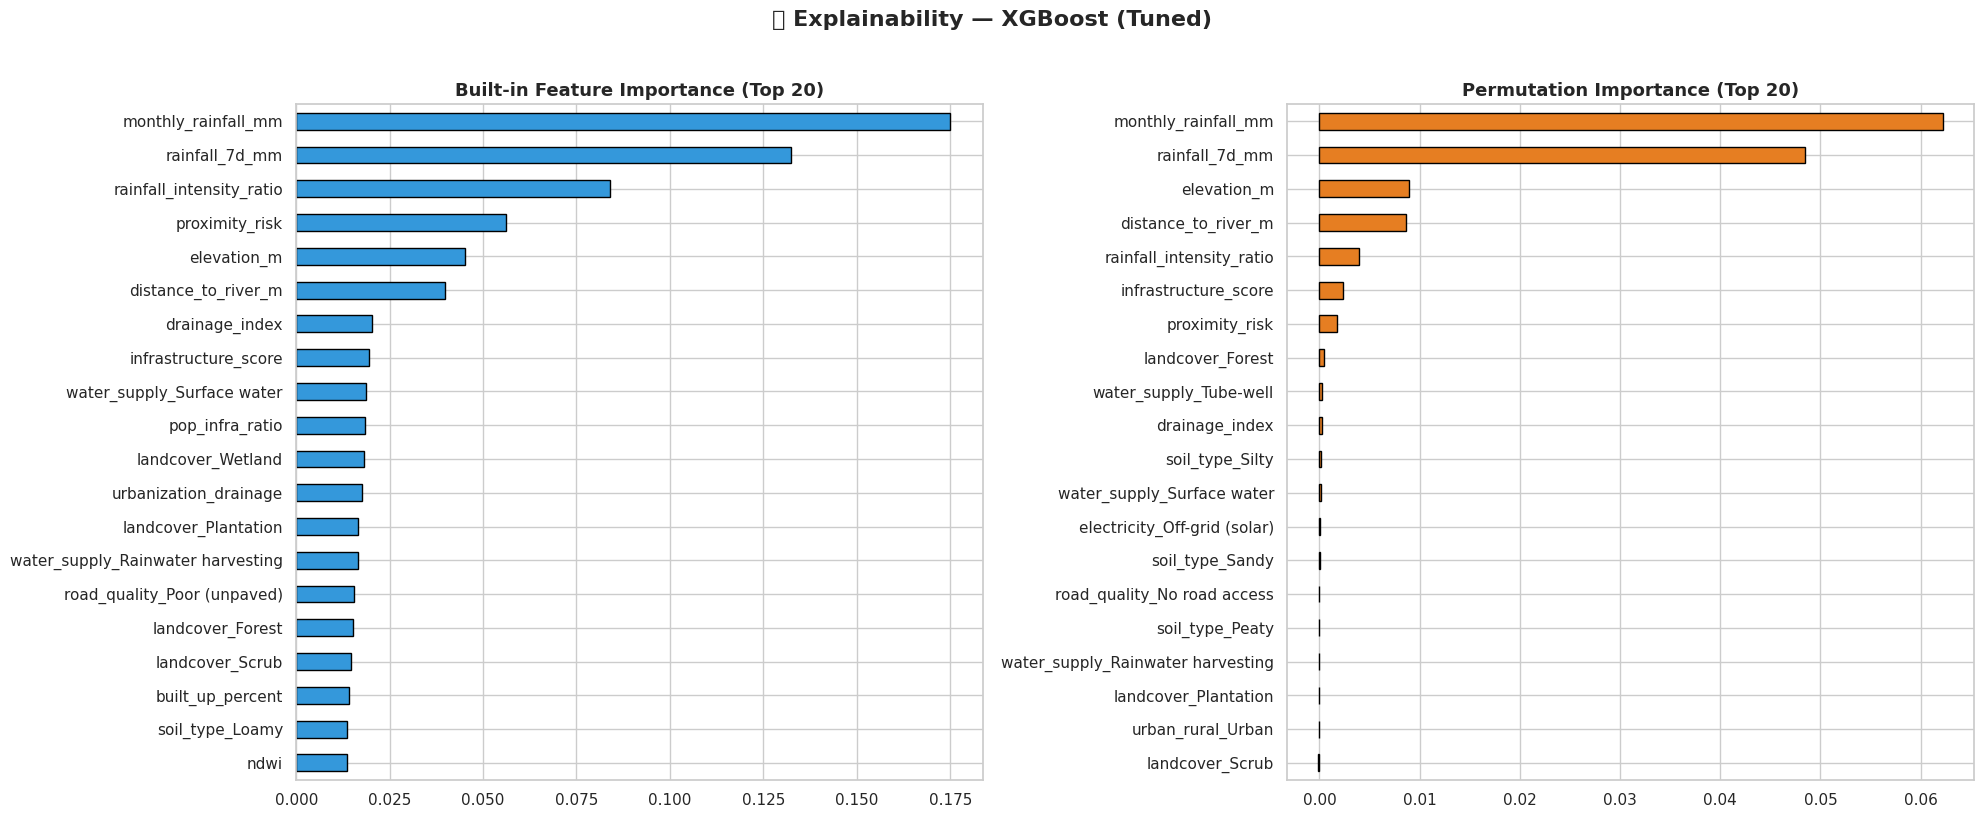


📌 Top 10 by Permutation Importance:
    1. monthly_rainfall_mm: 0.0622
    2. rainfall_7d_mm: 0.0484
    3. elevation_m: 0.0090
    4. distance_to_river_m: 0.0086
    5. rainfall_intensity_ratio: 0.0039
    6. infrastructure_score: 0.0023
    7. proximity_risk: 0.0018
    8. landcover_Forest: 0.0004
    9. water_supply_Tube-well: 0.0003
   10. drainage_index: 0.0002


In [ ]:
# ============================================================
# 17. EXPLAINABILITY
# ============================================================
from sklearn.inspection import permutation_importance

print(f'{"="*60}')
print('🧠 EXPLAINABILITY')
print(f'{"="*60}')

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Built-in importance
if hasattr(best_model, 'feature_importances_'):
    imp = pd.Series(best_model.feature_importances_, index=X_train.columns).sort_values(ascending=True)
    imp.tail(20).plot(kind='barh', ax=axes[0], color='#3498db', edgecolor='black')
    axes[0].set_title('Built-in Feature Importance (Top 20)', fontsize=13, fontweight='bold')
elif hasattr(best_model, 'coef_'):
    coefs = best_model.coef_[0] if best_model.coef_.ndim > 1 else best_model.coef_
    imp = pd.Series(np.abs(coefs), index=X_train.columns).sort_values(ascending=True)
    imp.tail(20).plot(kind='barh', ax=axes[0], color='#e74c3c', edgecolor='black')
    axes[0].set_title('Feature Coefficients (Top 20)', fontsize=13, fontweight='bold')
else:
    axes[0].text(0.5, 0.5, 'No built-in importance', transform=axes[0].transAxes, ha='center', fontsize=14)

# Permutation importance
print('  Computing permutation importance...')
perm_scoring = 'f1_weighted' if PROBLEM_TYPE == 'classification' else 'neg_root_mean_squared_error'
perm_result = permutation_importance(best_model, X_val, y_val, n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1, scoring=perm_scoring)
perm_imp = pd.Series(perm_result.importances_mean, index=X_val.columns).sort_values(ascending=True)
perm_imp.tail(20).plot(kind='barh', ax=axes[1], color='#e67e22', edgecolor='black')
axes[1].set_title('Permutation Importance (Top 20)', fontsize=13, fontweight='bold')

plt.suptitle(f'🧠 Explainability — {best_model_name}', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

print('\n📌 Top 10 by Permutation Importance:')
for rank, (feat, score) in enumerate(perm_imp.tail(10).sort_values(ascending=False).items(), 1):
    print(f'   {rank:2d}. {feat}: {score:.4f}')


🔬 SHAP Analysis...


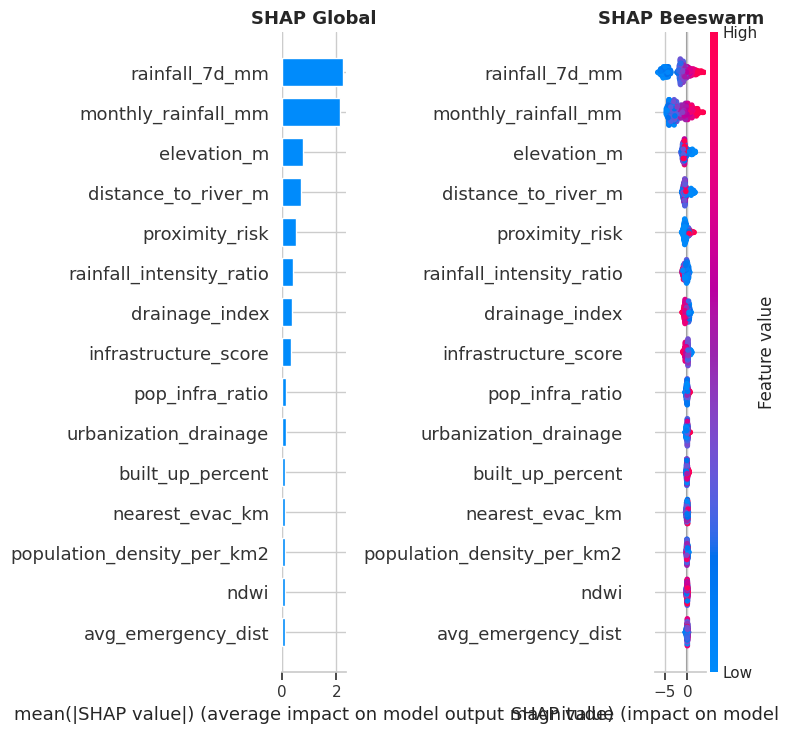

In [ ]:
# --- SHAP (if installed) ---
try:
    import shap
    print('\n🔬 SHAP Analysis...')
    X_shap = X_val.sample(min(500, len(X_val)), random_state=RANDOM_STATE)
    try:
        explainer = shap.TreeExplainer(best_model)
        shap_values = explainer.shap_values(X_shap)
    except Exception:
        try:
            bg = shap.sample(X_train, 100)
            explainer = shap.KernelExplainer(best_model.predict, bg)
            shap_values = explainer.shap_values(X_shap)
        except Exception as e:
            print(f'  SHAP failed: {e}')
            shap_values = None
    if shap_values is not None:
        sv = shap_values[1] if isinstance(shap_values, list) and len(shap_values) > 1 else (shap_values[0] if isinstance(shap_values, list) else shap_values)
        fig, axes = plt.subplots(1, 2, figsize=(20, 8))
        plt.sca(axes[0])
        shap.summary_plot(sv, X_shap, plot_type='bar', show=False, max_display=15)
        axes[0].set_title('SHAP Global', fontsize=13, fontweight='bold')
        plt.sca(axes[1])
        shap.summary_plot(sv, X_shap, show=False, max_display=15)
        axes[1].set_title('SHAP Beeswarm', fontsize=13, fontweight='bold')
        plt.tight_layout(); plt.show()
except ImportError:
    print('  ⚠️ SHAP not installed. pip install shap')

---
## 1️⃣9️⃣ Save Model + Download

In [ ]:
# ============================================================
# 19. SAVE MODEL + DOWNLOAD
# ============================================================

joblib.dump(best_model, 'model.pkl')

model_metadata = {
    'model_name': best_model_name,
    'model_type': type(best_model).__name__,
    'problem_type': PROBLEM_TYPE,
    'n_features': int(X_train.shape[1]),
    'feature_names': list(X_train.columns),
    'target_column': TARGET_COL,
    'cv_score_mean': float(cv_scores.mean()),
    'cv_score_std': float(cv_scores.std()),
    'baseline_beaten': True
}
with open('model_metadata.json', 'w') as f:
    json.dump(model_metadata, f, indent=2)

print(f'{"="*60}')
print('💾 MODEL SAVED')
print(f'{"="*60}')
print(f'  📄 model.pkl')
print(f'  📄 model_metadata.json')
print(f'  🏆 {best_model_name} — CV: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

# Download
try:
    from google.colab import files as colab_files
    print('\n📥 Downloading...')
    colab_files.download('model.pkl')
    colab_files.download('model_metadata.json')
    print('✅ Downloaded!')
except ImportError:
    import os
    print(f'\n📂 Files saved in: {os.getcwd()}')

print(f'\n🎉 Training pipeline complete!')

💾 MODEL SAVED
  📄 model.pkl
  📄 model_metadata.json
  🏆 XGBoost (Tuned) — CV: 0.9226 ± 0.0018

📥 Downloading...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Downloaded!

🎉 Training pipeline complete!
